In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

!pip install lime shap

import shap
from lime.lime_tabular import LimeTabularExplainer

import joblib

In [16]:
#2. LOAD DATA

import os
file_path = r'D:\MSC IT DA  Desertation\web app\default of credit card clients.xls'
df = pd.read_excel(file_path, header=1)

df.rename(columns={"default payment next month": "default"}, inplace=True)
df.drop(columns=["ID"], inplace=True)
print("Data loaded successfully!")
print(df.head())


Data loaded successfully!
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...          0          0          0         0       689         0   
1      0  ...       3272       3455       3261         0      1000      1000   
2      0  ...      14331      14948      15549      1518      1500      1000   
3      0  ...      28314      28959      29547      2000      2019      1200   
4      0  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default  

In [17]:
# ================================
# FEATURE ENGINEERING
# ================================

# Total bill amount
df["TOTAL_BILL"] = df[[
    "BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6"
]].sum(axis=1)

# Total payment
df["TOTAL_PAY"] = df[[
    "PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"
]].sum(axis=1)

# Payment ratio
df["PAY_RATIO"] = df["TOTAL_PAY"] / (df["TOTAL_BILL"] + 1)

# Average delay
df["AVG_DELAY"] = df[[
    "PAY_0","PAY_2","PAY_3",
    "PAY_4","PAY_5","PAY_6"
]].mean(axis=1)

In [18]:
X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (for LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:

# Keep original data
X_train_res, y_train_res = X_train, y_train

# Compute imbalance weight
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print("Class Distribution:", np.bincount(y_train))
print("Scale Pos Weight:", scale_pos_weight)

Class Distribution: [18691  5309]
Scale Pos Weight: 3.520625353173856


In [20]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
import xgboost as xgb

# ================================
# XGBOOST + HYPERPARAMETER TUNING
# ================================

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

# Handle imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

grid = GridSearchCV(
    xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist'
    ),
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Train with GridSearch
grid.fit(X_train_res, y_train_res)

# Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# ================================
# FINAL TRAINING (NO EARLY STOPPING)
# ================================

best_model.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [22]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [23]:
# 8. THRESHOLD TUNING
# ================================
thresholds = [0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_temp = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_temp))

# FINAL THRESHOLD (SELECTED)
y_pred = (y_prob > 0.5).astype(int)



Threshold: 0.2
              precision    recall  f1-score   support

           0       0.95      0.18      0.30      4673
           1       0.25      0.97      0.40      1327

    accuracy                           0.35      6000
   macro avg       0.60      0.57      0.35      6000
weighted avg       0.80      0.35      0.32      6000


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.93      0.42      0.58      4673
           1       0.30      0.88      0.45      1327

    accuracy                           0.52      6000
   macro avg       0.61      0.65      0.51      6000
weighted avg       0.79      0.52      0.55      6000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.66      0.76      4673
           1       0.38      0.73      0.50      1327

    accuracy                           0.68      6000
   macro avg       0.64      0.70      0.63      6000
weighted avg       0.78   

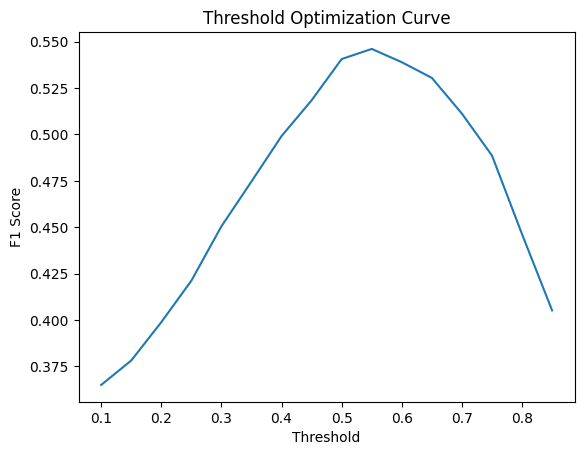

In [24]:
# 8.1 THRESHOLD OPTIMIZATION GRAPH
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    preds = (y_prob > t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Optimization Curve")
plt.show()

In [25]:
# 9. MODEL EVALUATION
# ================================
print("\nFinal XGBoost Model")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))



Final XGBoost Model
Accuracy: 0.7623333333333333
ROC-AUC: 0.7793568240066917
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4673
           1       0.47      0.63      0.54      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.72      0.69      6000
weighted avg       0.79      0.76      0.77      6000



In [26]:
# ================================
# 9.1 MODEL COMPARISON TABLE
# ================================

# Logistic predictions
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

# Random Forest predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# XGBoost already computed
# y_pred, y_prob

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob)
    ]
})

print(comparison)

                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.807667  0.707683
1        Random Forest  0.814833  0.755466
2              XGBoost  0.762333  0.779357


In [27]:
# 10. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[3735  938]
 [ 488  839]]


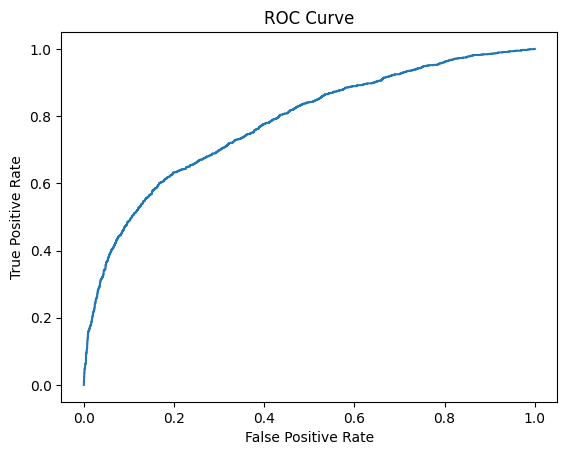

In [28]:
# 11. ROC CURVE
# ================================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


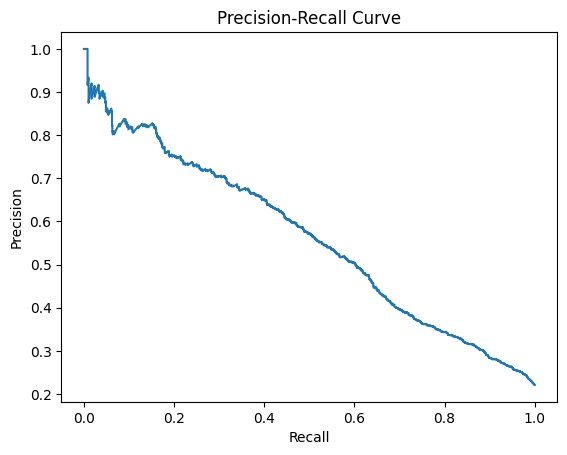

In [29]:
# 12. PRECISION-RECALL CURVE
# ================================
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

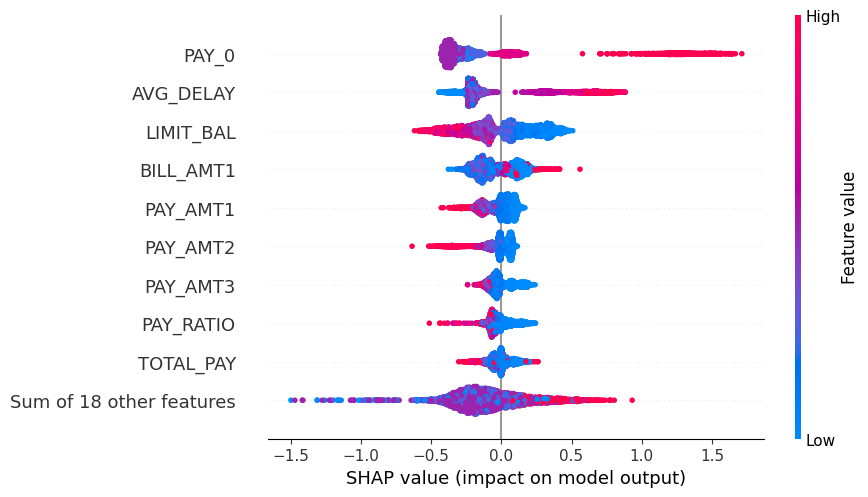

In [30]:
# 13. SHAP (GLOBAL EXPLAINABILITY)
# ================================
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)


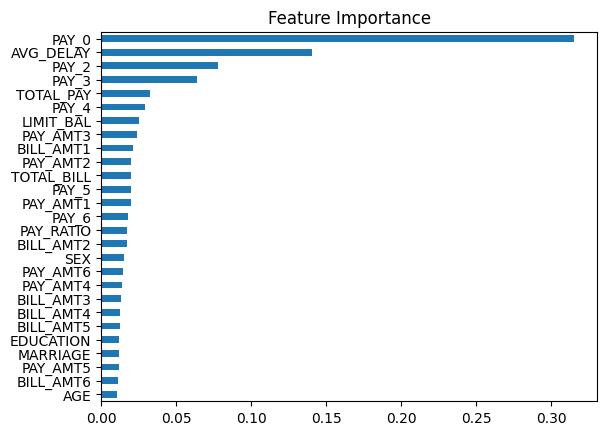

In [31]:
# 14. FEATURE IMPORTANCE
# ================================
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()


In [34]:
# 15. LIME (LOCAL EXPLAINABILITY)
# ================================

from IPython.display import display, HTML

# Generate the HTML first, then display it manually
html_data = exp.as_html()
display(HTML(html_data))

lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    mode="classification"
)

exp = lime_explainer.explain_instance(
    X_test.iloc[0].values,
    best_model.predict_proba
)
try:
    exp.show_in_notebook()
except ImportError:
    # If it errors out but already showed the plot, just ignore it
    pass



In [35]:
# 16. FAIRNESS ANALYSIS
# ================================
df_fair = X_test.copy()
df_fair["prediction"] = y_pred

male_rate = df_fair[df_fair["SEX"] == 1]["prediction"].mean()
female_rate = df_fair[df_fair["SEX"] == 2]["prediction"].mean()

print("Male Default Rate:", male_rate)
print("Female Default Rate:", female_rate)
print("Demographic Parity Difference:", abs(male_rate - female_rate))


Male Default Rate: 0.3263946711074105
Female Default Rate: 0.27598665925514176
Demographic Parity Difference: 0.05040801185226873


In [36]:
# 17. DSS (RISK CLASSIFICATION)
# ================================
def risk_level(p):
    if p < 0.25:
        return "Low Risk"
    elif p < 0.5:
        return "Medium Risk"
    else:
        return "High Risk"

risk = [risk_level(p) for p in y_prob]

results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_prob,
    "Risk Level": risk
})

print(results.head())


   Actual  Probability   Risk Level
0       0     0.382325  Medium Risk
1       0     0.329101  Medium Risk
2       0     0.371175  Medium Risk
3       1     0.316228  Medium Risk
4       0     0.109466     Low Risk


In [37]:
# 18. SAVE MODEL
# ================================
joblib.dump(best_model, "model.pkl")

['model.pkl']